<a href="https://colab.research.google.com/github/marstonsward/AAI-521-Computer-Vision-Image-Classification-Project/blob/main/01_data_preparation_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Team Project: AI-Generated vs Real Image Classification  
**Team Members:** Marston Ward, Jasper Dolar, Victor Salcedo  
**Date:** November 5, 2025  

This project uses a convolutional neural network (CNN) and transfer learning with ResNet to classify images as AI-generated or real. The dataset is sourced directly from Hugging Face (`Hemg/AI-Generated-vs-Real-Images-Datasets`) and analyzed in Google Colab using GPU acceleration.


In [1]:
%%time
# ---------------------------------
# Cell 1: Install Required Packages
# ---------------------------------
# Standard library imports
import os
import random

# Third-party imports
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from datasets import load_dataset
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, models, transforms

# 1. Determine the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

Using device: cuda
CPU times: user 3.31 s, sys: 412 ms, total: 3.72 s
Wall time: 3.73 s


### Cell 2: Load Dataset from Hugging Face

In this step, we load the **AI-Generated vs Real Images** dataset directly from Hugging Face using the `load_dataset()` function.  
This dataset contains labeled images — `0` for *real* photos and `1` for *AI-generated* images.  

By printing the dataset object, we can view its available splits (such as `train`, `validation`, or `test`) and confirm that the data has been successfully loaded into the Colab environment.  
Since it’s hosted online, there’s no need to manually upload or download files; Hugging Face automatically handles caching and version control.


In [2]:
%%time
# ----------------------------------------
# Cell 3: Load Dataset from Hugging Face
# ----------------------------------------

dataset = load_dataset("Hemg/AI-Generated-vs-Real-Images-Datasets")

# Check available splits
print(dataset)


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 152710
    })
})
CPU times: user 187 ms, sys: 43.2 ms, total: 230 ms
Wall time: 2.54 s


### Cell 4: Dataset Inspection and Class Distribution

This step explores the dataset to understand its structure and label balance.  
We first display a single sample image along with its label to verify that the dataset has loaded correctly and that each image is associated with the proper classification (`0` = Real, `1` = AI Generated).  

Next, we visualize the **class distribution** using a simple histogram.  
This helps determine whether the dataset is balanced or if one class dominates, which is important for model training and performance evaluation.  
Understanding the label distribution early on ensures that preprocessing and model design can address any imbalance if needed.


0


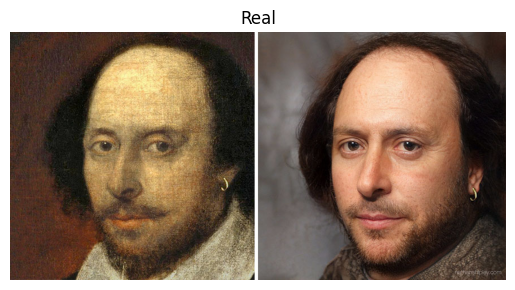

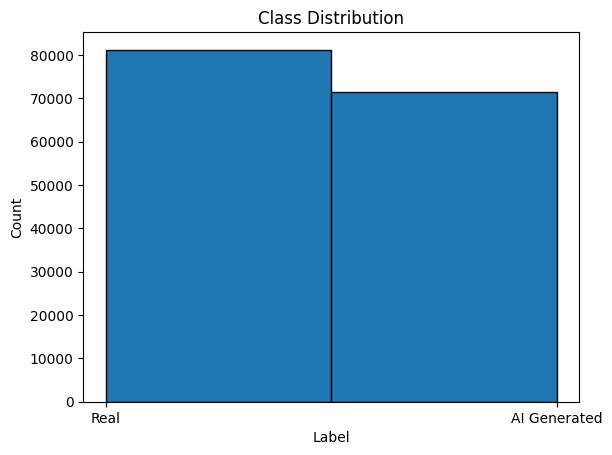

CPU times: user 1min 23s, sys: 3.18 s, total: 1min 26s
Wall time: 1min 26s


In [3]:
%%time
# ----------------------------------------
# Cell 5: Dataset Inspection and Class Distribution
# ----------------------------------------

# Inspect one sample
sample = dataset['train'][0]
print(sample['label'])
plt.imshow(sample['image'])
plt.title("AI Generated" if sample['label'] == 1 else "Real")
plt.axis('off')
plt.show()

# Class distribution
labels = [item['label'] for item in dataset['train']]
plt.hist(labels, bins=2, edgecolor='black')
plt.xticks([0,1], ['Real', 'AI Generated'])
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


### Cell 6: Real vs AI-Generated Image Comparison

In this step, we visualize one real image and one AI-generated image side by side for a direct comparison.  
By displaying both classes together, we can begin to notice subtle visual differences that may guide our model design — such as background smoothness, texture quality, or fine detail in features like hands or edges.  

This visual inspection provides an intuitive understanding of what distinguishes real photographs from AI-generated content and helps confirm that the labels in the dataset are accurate and meaningful before moving on to preprocessing and model training.


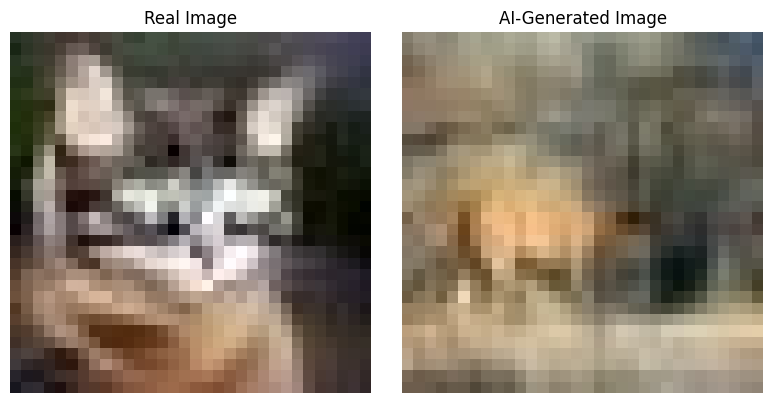

CPU times: user 2min 51s, sys: 11 s, total: 3min 2s
Wall time: 3min 2s


In [4]:
%%time
# ----------------------------------------
# Cell 7: Real vs AI-Generated Image Comparison
# ----------------------------------------


# Separate real and AI-generated images
real_samples = [x['image'] for x in dataset['train'] if x['label'] == 0]
fake_samples = [x['image'] for x in dataset['train'] if x['label'] == 1]

# Randomly select one from each
real_img = random.choice(real_samples)
fake_img = random.choice(fake_samples)

# Display side by side
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(real_img)
ax[0].set_title("Real Image")
ax[0].axis('off')

ax[1].imshow(fake_img)
ax[1].set_title("AI-Generated Image")
ax[1].axis('off')

plt.tight_layout()
plt.show()


### Cell 8: Image Transforms (Feature Engineering)

Here we define image transformation pipelines that prepare the data for training and evaluation.  
These transformations standardize image dimensions, improve model generalization, and match the preprocessing expected by pre-trained models such as ResNet.

For the **training set**, we include augmentation techniques — random flips, rotations, and slight color variations — to expose the model to more diverse visual examples and reduce overfitting.  
The images are resized to **224×224 pixels** (a standard input size for CNN and ResNet models), converted to tensors, and normalized using ImageNet mean and standard deviation values.

For the **validation and test sets**, we apply only resizing and normalization to ensure consistent evaluation without altering the original visual characteristics.


In [5]:
%%time
# ----------------------------------------
# Cell 9: Image Transforms (Feature Engineering)
# ----------------------------------------
# These transforms apply to both the CNN and ResNet models.
# Training set transformations: resize, augment, normalize
# The normalized mean across ImageNet is [0.485, 0.456, 0.406]
# The standard deviation across ImageNet is [0.229, 0.224, 0.225]
# These are specific ImageNet mean and standard deviation values.

height, width = 224, 224
resnet_mean = [0.485, 0.456, 0.406]
resnet_std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((height, width)),      # standard input size
    transforms.Lambda(lambda image: image.convert("RGB")), # Ensure 3 channels
    transforms.RandomHorizontalFlip(p=0.5),  # flip for variation
    transforms.RandomRotation(10),           # small rotations
    transforms.ColorJitter(brightness=0.1,
                           contrast=0.1,
                           saturation=0.1,
                           hue=0.05),        # small color shifts
    transforms.ToTensor(),                   # convert to tensor, scales [0,1]
    transforms.Normalize(           # normalize RGB channels (ImageNet stats)
        mean=resnet_mean,
        std=resnet_std
    )
])

# Validation / Test set transformations: resize + normalize (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((height, width)),
    transforms.Lambda(lambda image: image.convert("RGB")), # Ensure 3 channels
    transforms.ToTensor(),
    transforms.Normalize(
        mean=resnet_mean,
        std=resnet_std
    )
])

CPU times: user 425 µs, sys: 0 ns, total: 425 µs
Wall time: 432 µs


### Cell 10: Full Dataset Split and DataLoader Preparation

This version of the data preparation step now uses the **entire dataset**.  
All available images are included, providing a more complete representation of both real and AI-generated samples for training, validation, and testing.

The dataset is shuffled to ensure randomness, then split into:
- **80%** for training  
- **10%** for validation  
- **10%** for testing  

Each split is wrapped in a PyTorch `DataLoader` for efficient batch processing.  
Using the full dataset improves model performance and generalization but also increases training time and memory usage.  
It is recommended to run this version in **Google Colab with GPU and High-RAM settings** to avoid resource limitations.


In [6]:
%%time
# ----------------------------------------------------------
# Cell 11: Dataset Wrapper, Shuffle, and Split (Full Dataset)
# ----------------------------------------------------------

# Extract images and labels
images = [x['image'] for x in dataset['train']]
labels = [x['label'] for x in dataset['train']]

# Shuffle dataset
combined = list(zip(images, labels))
random.shuffle(combined)
images, labels = zip(*combined)

# Dataset class
class HuggingFaceImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# Use full dataset
subset_size = len(images)

# Split data: 80% train, 10% val, 10% test
train_end = int(0.8 * subset_size)
val_end = int(0.9 * subset_size)

train_images = images[:train_end]
val_images = images[train_end:val_end]
test_images = images[val_end:]

train_labels = labels[:train_end]
val_labels = labels[train_end:val_end]
test_labels = labels[val_end:]

# Create datasets
train_dataset = HuggingFaceImageDataset(train_images, train_labels, transform=train_transforms)
val_dataset = HuggingFaceImageDataset(val_images, val_labels, transform=val_transforms)
test_dataset = HuggingFaceImageDataset(test_images, test_labels, transform=val_transforms)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Output sizes
print(f"Train: {len(train_dataset)} images")
print(f"Val: {len(val_dataset)} images")
print(f"Test: {len(test_dataset)} images")


Train: 122168 images
Val: 15271 images
Test: 15271 images
CPU times: user 2min 51s, sys: 11.1 s, total: 3min 2s
Wall time: 3min 2s


### Cell 12: Verify DataLoader and Visualize Augmented Images

This step verifies that the DataLoader is working correctly and that the image transformations are being applied as expected.  
A batch of training images is loaded, and a sample grid of eight images is displayed after augmentation and normalization.  

The `imshow()` function reverses the normalization process so that the images appear in natural color.  
By plotting a mix of real and AI-generated samples, this visualization confirms that the data is correctly labeled, augmented, and ready for model training.  
Slight rotations, flips, and color variations seen here reflect the transformations defined earlier in the training pipeline.


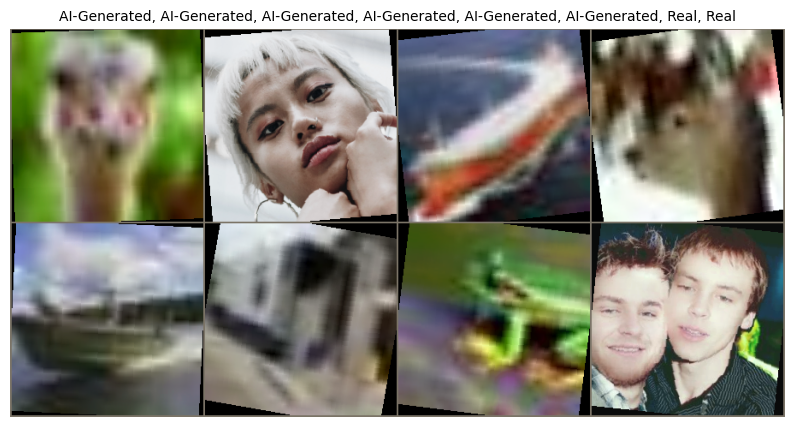

CPU times: user 1.4 s, sys: 5.3 ms, total: 1.4 s
Wall time: 507 ms


In [7]:
%%time
# ----------------------------------------
# Cell 13: Verify DataLoader and Visualize Augmented Images
# ----------------------------------------

def imshow(img):
    # Undo normalization using ImageNet stats
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean  # de-normalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')

# Get one batch from DataLoader
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Display first 8 images
plt.figure(figsize=(10, 10))
grid = torchvision.utils.make_grid(images[:8], nrow=4, padding=2)
imshow(grid)

# Create dynamic title list
titles = ['AI-Generated' if lbl == 1 else 'Real' for lbl in labels[:8]]
plt.title(", ".join(titles), fontsize=10)
plt.show()


### Next Steps: Running the Code and Training Models (CNN and Transfer Learning)

With preprocessing complete and DataLoaders ready, your notebook is fully set up for model training and evaluation.  
Follow these steps to ensure smooth performance and consistent results.

---

#### **1. Configure the Runtime Environment**
- Open this notebook in **Google Colab**.  
- Go to **Runtime → Change runtime type → Hardware accelerator → GPU**.  
- Under **Runtime shape**, select **High-RAM** to prevent memory errors during training.  
  (Runtime → Change runtime type → Select “High-RAM” option if available.)  
- Click **Save**, then **Reconnect** when prompted.  

This setup ensures faster training and enough memory to handle the full dataset.

---

#### **2. Run All Cells in Order**
Execute each notebook cell sequentially:

1. **Cell 1 – Install Packages:** Installs all dependencies (`torch`, `torchvision`, `datasets`, `matplotlib`, etc.).  
2. **Cell 2 – Import Libraries:** Imports required modules.  
3. **Cell 3 – Load Dataset:** Loads the dataset directly from Hugging Face.  
4. **Cell 4 – Dataset Inspection:** Displays sample images and label distribution.  
5. **Cell 5 – Real vs AI-Generated Comparison:** Shows example images from each class.  
6. **Cell 6 – Image Transforms:** Defines augmentations and normalization for both CNN and ResNet models.  
7. **Cell 7 – Dataset Split and DataLoaders:** Shuffles data, splits into train/validation/test sets, and builds loaders.  
8. **Cell 8 – Verify DataLoaders:** Displays augmented training images to confirm transformations.

After running these cells, your `train_loader`, `val_loader`, and `test_loader` objects will be ready for model training.

---

# Model Creation and Training
Create a convolutional neural network (CNN) model for classifying images as AI-generated or real, train the model using the `train_loader`, `val_loader`, and `test_loader` across multiple epochs, and save the best performing model based on validation metrics. After training, visualize the training history (loss and accuracy curves) and evaluate the final performance of the best model on the test set. Finally, summarize the entire CNN model development process, discuss its performance, and outline potential next steps, such as exploring transfer learning with ResNet.

In [8]:
class CNN(nn.Module):
    def __init__(self, num_classes=1):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)

        # Calculate flattened features size dynamically
        # Input image size is 224x224. After 3 pooling layers (each 2x2), size becomes 224/8 = 28
        # So, the size before the first linear layer is 128 * 28 * 28
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 28 * 28) # Flatten the tensor
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Instantiate the CNN model
model = CNN(num_classes=1).to(device)

# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("CNN model, loss function, and optimizer defined.")

CNN model, loss function, and optimizer defined.


In [9]:
def train_epoch(model, dataloader, criterion, optimizer, device, scaler=None):
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device) # Ensure labels are float and have shape (batch_size, 1)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass with Automatic Mixed Precision
        with torch.amp.autocast(device_type='cuda', enabled=scaler is not None):
            outputs = model(images)
            loss = criterion(outputs, labels)

        if scaler is not None:
            # Backward pass and optimize with scaler
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            # Standard backward pass and optimize
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Calculate accuracy
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    return epoch_loss, epoch_accuracy

print("train_epoch function defined with AMP support.")

train_epoch function defined with AMP support.


In [10]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():  # Disable gradient calculation during evaluation
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device) # Ensure labels are float and have shape (batch_size, 1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    return epoch_loss, epoch_accuracy

print("evaluate_model function defined.")

evaluate_model function defined.


In [11]:
num_epochs = 10 # Define the number of epochs
best_val_accuracy = -1.0 # Initialize with a low value
best_model_path = '/content/sample_data/best_cnn_model.pth' # Save model to persistent storage

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Initialize Automatic Mixed Precision (AMP) scaler
scaler = torch.amp.GradScaler(device='cuda')

# Check if a trained model already exists
if os.path.exists(best_model_path):
    print(f"Loading pre-trained model from {best_model_path}")
    model.load_state_dict(torch.load(best_model_path))
    model.eval() # Set to evaluation mode after loading
    print("Pre-trained model loaded successfully.")
else:
    print("No pre-trained model found. Starting training...")
    for epoch in range(num_epochs):
        # Train the model for one epoch
        train_loss, train_accuracy = train_epoch(model, train_loader, criterion, optimizer, device, scaler=scaler)
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        # Evaluate the model on the validation set
        val_loss, val_accuracy = evaluate_model(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs}:\n"\
              f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}\n"\
              f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

        # Save the best model
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), best_model_path)
            print(f"Saved best model with validation accuracy: {best_val_accuracy:.4f}")

    print("Training complete.")

No pre-trained model found. Starting training...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/10:
Train Loss: 0.7295, Train Accuracy: 0.6938
Val Loss: 0.4635, Val Accuracy: 0.7620
Saved best model with validation accuracy: 0.7620
Epoch 2/10:
Train Loss: 0.4539, Train Accuracy: 0.7494
Val Loss: 0.3795, Val Accuracy: 0.7845
Saved best model with validation accuracy: 0.7845
Epoch 3/10:
Train Loss: 0.4111, Train Accuracy: 0.7707
Val Loss: 0.3346, Val Accuracy: 0.8057
Saved best model with validation accuracy: 0.8057
Epoch 4/10:
Train Loss: 0.3840, Train Accuracy: 0.7830
Val Loss: 0.3288, Val Accuracy: 0.8096
Saved best model with validation accuracy: 0.8096
Epoch 5/10:
Train Loss: 0.3674, Train Accuracy: 0.7924
Val Loss: 0.3245, Val Accuracy: 0.8109
Saved best model with validation accuracy: 0.8109
Epoch 6/10:
Train Loss: 0.3505, Train Accuracy: 0.8139
Val Loss: 0.3111, Val Accuracy: 0.8532
Saved best model with validation accuracy: 0.8532
Epoch 7/10:
Train Loss: 0.3252, Train Accuracy: 0.8471
Val Loss: 0.2698, Val Accuracy: 0.8832
Saved best model with validation accuracy:

### Evaluation Dataset: `PrithviMLMods:AI-vs-Deepfake-vs-Real` images

To further test the generalization capabilities of our trained CNN model, we will evaluate it on a completely new dataset that is truly a challenge for humans to distinguish. This dataset contains a mix of real and AI-generated (synthetic) human faces, providing a different domain than the initial dataset used for training.

In [16]:
%%time
# Load the new dataset
new_dataset_hf = load_dataset("prithivMLmods/AI-vs-Deepfake-vs-Real")

print(new_dataset_hf)

# We'll use the 'train' split as a new test set

# Inspect the features of the dataset to ensure we get the correct label
# print(new_dataset_hf['train'].features)
# According to the dataset card, 'label' mapping might be different.
# Assuming for now that 'Real' is 0, and 'AI'/'Deepfake' are 1.
# We will need to confirm the exact label mapping for this dataset.

new_test_images = []
new_test_labels = []

# Iterate through the dataset to handle potential multiple labels or verify binary mapping
for item in new_dataset_hf['train']:
    new_test_images.append(item['image'])
    # This dataset appears to have 3 classes (0:AI, 1:Deepfake, 2:Real)
    # We want to map 2 (Real) to 0, and 0 (AI) and 1 (Deepfake) to 1.
    if item['label'] == 2:
        new_test_labels.append(0) # Map Real to 0
    else:
        new_test_labels.append(1) # Map AI or Deepfake to 1

print(f"Loaded {len(new_test_images)} images for new dataset evaluation.")

README.md: 0.00B [00:00, ?B/s]

0000.parquet:   0%|          | 0.00/508M [00:00<?, ?B/s]

0001.parquet:   0%|          | 0.00/506M [00:00<?, ?B/s]

0002.parquet:   0%|          | 0.00/521M [00:00<?, ?B/s]

0003.parquet:   0%|          | 0.00/422M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9999 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 9999
    })
})
Loaded 9999 images for new dataset evaluation.
CPU times: user 1min 5s, sys: 27 s, total: 1min 32s
Wall time: 1min 44s


In [17]:
# Create a dataset and dataloader for the new dataset using val_transforms
new_test_dataset = HuggingFaceImageDataset(new_test_images, new_test_labels, transform=val_transforms)
new_test_loader = DataLoader(new_test_dataset, batch_size=32, shuffle=False)

print(f"New Test Dataset size: {len(new_test_dataset)} images")

New Test Dataset size: 9999 images


In [18]:
print("Evaluating model on the new `face_synthetics` dataset...")

# Ensure the best model is loaded for evaluation
# The 'model' variable should already contain the best_cnn_model from previous steps
# If you're running this in a fresh session, ensure model is re-instantiated and best_model_path is set correctly

# Load the best model's weights if not already loaded (e.g., if you ran this in a new session)
if not isinstance(model, CNN) or not hasattr(model, 'conv1'): # Basic check if model is not the expected type or uninitialized
    model = CNN(num_classes=1).to(device)
    model.load_state_dict(torch.load(best_model_path))
    model.eval() # Set to evaluation mode

# Evaluate on the new test set
new_test_loss, new_test_accuracy = evaluate_model(model, new_test_loader, criterion, device)

print(f"\nEvaluation on `face_synthetics` Dataset:")
print(f"New Test Loss: {new_test_loss:.4f}")
print(f"New Test Accuracy: {new_test_accuracy:.4f}")

Evaluating model on the new `face_synthetics` dataset...

Evaluation on `face_synthetics` Dataset:
New Test Loss: 0.9358
New Test Accuracy: 0.4617


Visualizing sample images from the Prithvi dataset with detailed labels (above images)...


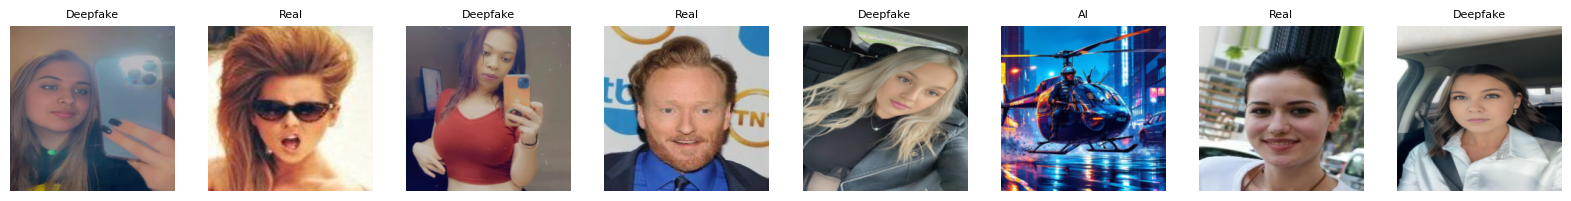

In [24]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# Reuse the imshow function for denormalization and display
def imshow(img):
    # Undo normalization using ImageNet stats
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean  # de-normalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')

print("Visualizing sample images from the Prithvi dataset with detailed labels (above images)...")

# Define the label mapping for the Prithvi dataset
prithvi_label_map = {
    0: 'AI',
    1: 'Deepfake',
    2: 'Real'
}

# Select 8 random indices from the dataset
num_samples_to_show = 8
random_indices = random.sample(range(len(new_dataset_hf['train'])), num_samples_to_show)

sampled_images = []
sampled_labels_str = []

for idx in random_indices:
    item = new_dataset_hf['train'][idx]
    image = item['image']
    original_label = item['label']

    # Apply the validation transforms
    transformed_image = val_transforms(image)

    sampled_images.append(transformed_image)
    sampled_labels_str.append(prithvi_label_map[original_label])

# Display the sampled images with individual titles
fig, axes = plt.subplots(1, num_samples_to_show, figsize=(2 * num_samples_to_show, 2))

for i, (img, label_str) in enumerate(zip(sampled_images, sampled_labels_str)):
    ax = axes[i]
    img_np = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean  # de-normalize
    img_np = np.clip(img_np, 0, 1)
    ax.imshow(img_np)
    ax.set_title(label_str, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

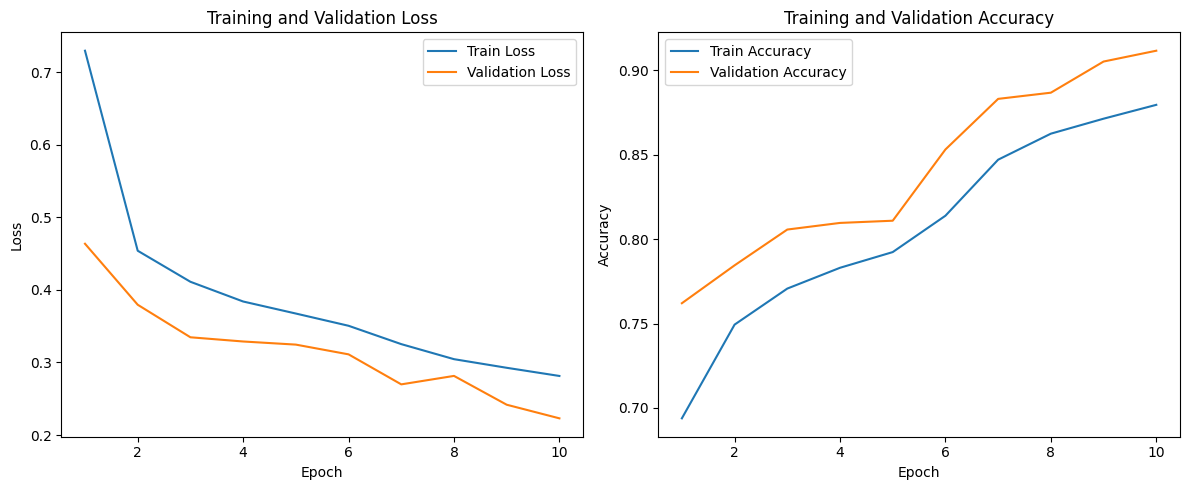


Final Test Loss on original dataset: 0.2277
Final Test Accuracy on original dataset: 0.9123

Test Loss on Prithiv dataset: 0.9358
Test Accuracy on Prithiv dataset: 0.4617


In [21]:
import matplotlib.pyplot as plt

# Ensure the best model is loaded for evaluation on the original test set
# This block is added to ensure test_loss and test_accuracy are defined
# (They might not be if cells were run out of order or kernel reset)
model.load_state_dict(torch.load(best_model_path))
model.eval()
original_test_loss, original_test_accuracy = evaluate_model(model, test_loader, criterion, device)

# Plotting training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Train Accuracy')
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nFinal Test Loss on original dataset: {original_test_loss:.4f}")
print(f"Final Test Accuracy on original dataset: {original_test_accuracy:.4f}")
print(f"\nTest Loss on Prithiv dataset: {new_test_loss:.4f}")
print(f"Test Accuracy on Prithiv dataset: {new_test_accuracy:.4f}")

The trained model makes predictions even if it has never seen the Prithvi dataset during its training phase, it still has learned weights and biases from the original training data. When Prithvi images is fed into the trained model during evaluation, the model performs a forward pass and produces predictions (logits in this case) for each image. The loss function (nn.BCEWithLogitsLoss) then takes these predictions and compares them against the true labels of the Prithvi dataset (which we know, as it's a labeled test set). The loss value quantifies the average "error" or "discrepancy" between what the model predicted and what the true labels actually are. A high loss on an unseen dataset, especially one from a different domain, indicates that the model has not generalized well to that new data distribution. In this case, the high loss (0.9358) and low accuracy (0.4617) on the Prithvi dataset clearly show that the features the model learned from the Hemg dataset are not effective for classifying images in the prithivMLmods/AI-vs-Deepfake-vs-Real dataset.

So, while the model wasn't trained on the Prithvi dataset, it can still predict on it, and the loss function can still evaluate how good those predictions are.

### Why did the model perform poorly on the Prithvi dataset?

The significant drop in accuracy from approximately **91%** on the original test set to **46%** on the `prithivMLmods/AI-vs-Deepfake-vs-Real` dataset (Prithvi dataset) indicates a clear **generalization gap** and **domain shift**.

Here are the primary reasons for this poor performance:

1.  **Domain Shift**: The original dataset (`Hemg/AI-Generated-vs-Real-Images-Datasets`) likely contains a wide variety of images (e.g., landscapes, objects, general scenes, some faces). In contrast, the Prithvi dataset is specifically focused on **human faces**, and importantly, includes **deepfakes**. The visual characteristics and artifacts distinguishing AI-generated faces/deepfakes from real faces are often different from those found in general AI-generated images.
    *   Your model learned features specific to the `Hemg` dataset. These features might not be relevant or sufficient to detect manipulations or specific patterns in AI-generated and deepfake human faces.

2.  **Feature Specialization**: The CNN, having been trained on a general dataset, likely specialized in detecting general AI artifacts (e.g., blurred backgrounds, unusual textures, color shifts) present across various image types. It did not learn the nuanced, subtle, and often very specific features that differentiate real human faces from sophisticated AI-generated or deepfake human faces.

3.  **Lack of Representativeness**: The Prithvi dataset represents a new distribution of data that was not adequately represented in the original training data. The model encountered patterns and visual challenges it had never seen before during training, leading to essentially random classification (an accuracy of ~46% is close to guessing for a binary classification task).

4.  **Complexity of Deepfake Detection**: Detecting deepfakes, in particular, is a challenging task that often requires highly specialized models and datasets. Deepfakes are designed to be visually convincing, and the artifacts can be very subtle.

**In summary, the model's poor performance on the Prithvi dataset is a classic example of a model failing to generalize to a new domain because the new data's characteristics are fundamentally different from the data it was trained on.**

To address this, **Transfer Learning with a pre-trained model on a large, diverse dataset (like ResNet on ImageNet) and fine-tuning on a dataset more similar to the Prithvi dataset** would be the recommended approach. This allows the model to leverage robust, general-purpose features learned from a vast amount of images, which can then be adapted to the specific nuances of facial images and deepfake detection.